In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Samuele Taviano
# Matricole: 660185, ?

In [2]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import cup_common as cc
import cross_common as cr
import importlib
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
importlib.reload(cc)
df_train, df_test = cc.load_set()
scaler = StandardScaler()
X_tr, y_tr = cc.prepare_dataset(df_train, scaler=scaler, fit_scaler=True)
X_ts, y_ts = cc.prepare_dataset(df_test, scaler=scaler, fit_scaler=False)
features_names = X_tr.columns
cr.dataset_introspection(df_train, df_test)

,Property,Training,Test
0,Number of samples,500,1000
1,Number of features,15,11
2,Class values,[],[]
3,Class balance,[],[]


In [4]:
df_train.head()

,id,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,t1,t2,t3,t4
0,1,-6.925642,-6.093158,-9.149763,-5.918488,4.391259,-1.059304,-5.031085,-6.932177,-5.805652,7.147028,4.555533,-5.694865,6.554997,10.688732,15.416160,-7.535628
1,2,-5.649870,-7.650998,-10.407383,-7.864047,3.790306,-1.673732,-8.493233,-8.143588,-9.447557,10.790796,6.266211,-5.551301,12.342252,-8.135250,23.787661,-3.270978
2,3,15.985886,14.192953,24.466835,12.551305,-7.788409,0.557977,23.145951,20.031774,14.516358,-21.024198,-10.410913,12.061133,28.542661,-14.132383,-56.408372,1.892238
3,4,12.774004,10.156462,18.588934,8.346695,-5.245173,-0.199274,14.500231,12.608063,12.411055,-15.479452,-8.871887,6.703585,20.253500,9.525402,-0.673842,40.295464
4,5,-4.019226,-4.043457,-5.095354,-3.147125,0.725466,-0.477673,-4.025913,-0.995364,-3.491760,3.385533,1.838361,-4.271710,-3.588910,6.050010,1.198489,-11.677909


In [5]:
df_test.head()

,id,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12
0,1,-1.948207,-4.831121,-8.003946,-3.268500,2.222619,-1.595923,-5.323413,-3.541106,-2.668865,3.108137,3.501315,-2.778303
1,2,14.990087,13.501754,25.691005,11.910876,-8.300274,0.364864,23.035523,17.730048,12.980467,-19.740962,-8.864486,10.315840
2,3,2.893488,4.681421,7.148577,3.731728,-1.834960,-2.965363,5.521146,5.255667,1.841639,-2.679762,-1.766710,2.563493
3,4,11.892590,9.223032,13.903191,7.440720,-6.288820,0.694170,17.971045,13.520892,11.306512,-12.436463,-5.639603,6.603149
4,5,13.459402,12.502286,23.704447,12.784438,-8.024671,-0.279835,17.446072,13.328186,12.805979,-14.407507,-8.312281,10.776876


In [6]:
print(features_names)

Index(['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11',
       'x12'],
      dtype='object')


In [7]:
X_tr.head()

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12
0,-0.887331,-0.811595,-0.736261,-0.815968,0.956012,-0.007815,-0.613051,-0.918149,-0.745905,0.730527,0.838831,-0.922788
1,-0.763180,-0.968103,-0.812697,-1.037309,0.852481,-0.425551,-0.866649,-1.022567,-1.100045,1.021196,1.092561,-0.902803
2,1.342279,1.226455,1.306918,1.285290,-1.142278,1.091741,1.450876,1.406032,1.230212,-1.516739,-1.381011,1.548933
3,1.029718,0.820928,0.949665,0.806943,-0.704134,0.576902,0.817589,0.766139,1.025492,-1.074425,-1.152740,0.803137
4,-0.604496,-0.605671,-0.489838,-0.500677,0.324476,0.387625,-0.539424,-0.406420,-0.520902,0.430466,0.435817,-0.724678


In [8]:
X_ts.head()

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12
0,-0.402957,-0.684804,-0.666619,-0.514486,0.582403,-0.372650,-0.634464,-0.625852,-0.440883,0.408338,0.682469,-0.516788
1,1.245374,1.157014,1.381321,1.212430,-1.230461,0.960448,1.442787,1.207633,1.080862,-1.414373,-1.151643,1.305980
2,0.068207,0.270876,0.254334,0.281911,-0.116629,-1.303704,0.159884,0.132393,-0.002281,-0.053372,-0.098892,0.226816
3,0.943945,0.727151,0.664871,0.703873,-0.883932,1.184336,1.071821,0.844821,0.918086,-0.831681,-0.673324,0.789155
4,1.096417,1.056602,1.260580,1.311813,-1.182981,0.522130,1.033368,0.828211,1.063895,-0.988914,-1.069739,1.370159


<p>Check if custom fit in 'prepare_dataset' match the standard scaler.</p>

In [9]:
scaler_ref = StandardScaler()

# Sanity check TR
X_tr_unscaled = df_train.drop(columns=["id"] + cc.output_columns).astype(np.float32)
X_tr_scaled = scaler_ref.fit_transform(X_tr_unscaled)

# 3) Confronto numerico
np.testing.assert_allclose(
    X_tr.to_numpy(),
    X_tr_scaled,
    rtol=1e-6,
    atol=1e-7
)

print("Sanity check on TR passed: prepare_dataset == scaler.fit_transform")

# Sanity check TS
X_ts_unscaled = df_test.drop(columns=["id"]).astype(np.float32)
X_ts_scaled = scaler_ref.transform(X_ts_unscaled)

np.testing.assert_allclose(
    X_ts.to_numpy(),
    X_ts_scaled,
    rtol=1e-6,
    atol=1e-7
)

print("Sanity check on TS passed: prepare_dataset == scaler.fit_transform")

Sanity check on TR passed: prepare_dataset == scaler.fit_transform
Sanity check on TS passed: prepare_dataset == scaler.fit_transform


In [10]:
y_tr

array([[  6.5549965,  10.688732 ,  15.416161 ,  -7.535628 ],
       [ 12.342253 ,  -8.13525  ,  23.78766  ,  -3.2709775],
       [ 28.542662 , -14.132383 , -56.40837  ,   1.8922378],
       ...,
       [-11.158948 , -27.36821  , -22.150507 ,  31.95089  ],
       [ 17.969044 ,   2.4826617,  31.653538 ,  -1.5510315],
       [ -5.5437155,  17.841112 ,  -4.228595 ,  29.969604 ]],
      shape=(500, 4), dtype=float32)

In [11]:
y_ts

In [12]:
print(type(X_tr), type(y_tr), type(X_tr), type(y_ts))
print(y_tr.shape)

<class 'pandas.core.frame.DataFrame'> <class 'numpy.ndarray'> <class 'pandas.core.frame.DataFrame'> <class 'NoneType'>
(500, 4)


<hr/>

<h4>Data Analysis</h4>

<h5>Data Distribution</h5>
<p>The analysis starts from the distribution of the target variable.</p>

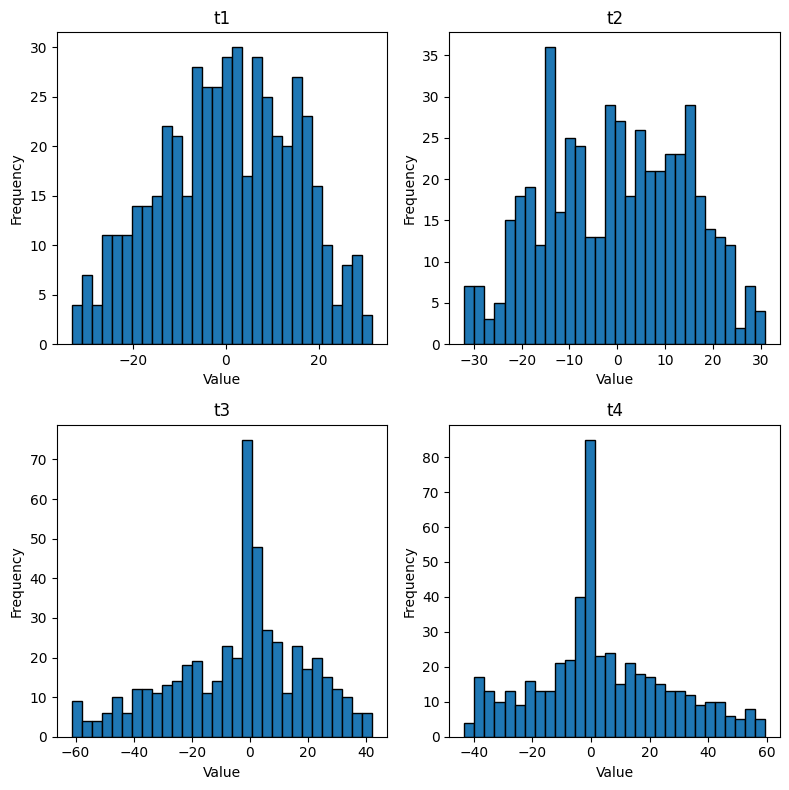

In [13]:
# Target cols t1,t2,t3,t4
target_cols = df_train.columns[-4:]
y = df_train[target_cols]

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()

for i, col in enumerate(target_cols):
    axes[i].hist(y[col], bins=30, edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [14]:
for i in [1,2,3,4]:
    min = df_train[f't{i}'].min()
    max = df_train[f't{i}'].max()
    range_data = max - min
    print(f"t{i} range: {range_data} - min: {min} - max: {max}")

t1 range: 64.71229006960431 - min: -33.1278722410254 - max: 31.5844178285789
t2 range: 62.8021525259471 - min: -31.9476741713948 - max: 30.8544783545523
t3 range: 103.5380732487684 - min: -61.2639474160249 - max: 42.2741258327435
t4 range: 102.4990213260183 - min: -43.1537971048941 - max: 59.3452242211242


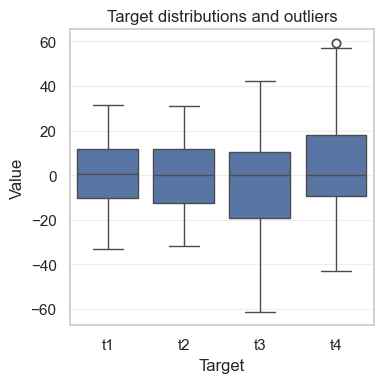

In [15]:
# reshape
df_long = df_train[["t1", "t2", "t3", "t4"]].melt(
    var_name="Target",
    value_name="Value"
)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(4, 4))
sns.boxplot(data=df_long,x="Target",y="Value",showfliers=True)
plt.title("Target distributions and outliers")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

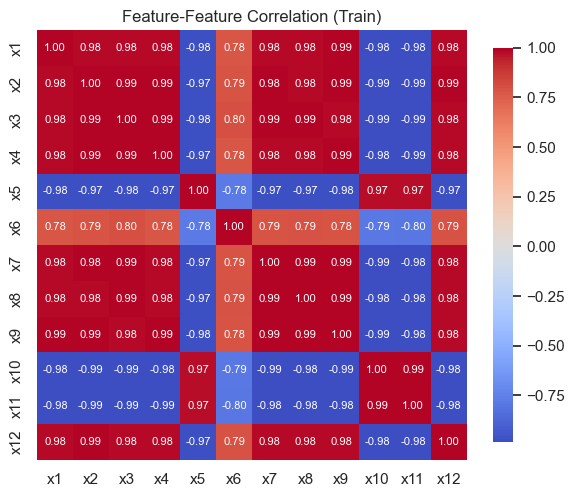

In [16]:
corr_matrix = X_tr.corr(method="pearson")

plt.figure(figsize=(6, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={"size": 8},
    center=0,
    square=True,
    cbar_kws={"shrink": 0.7,"aspect": 20},
)

plt.title("Feature-Feature Correlation (Train)")
plt.tight_layout()
plt.show()

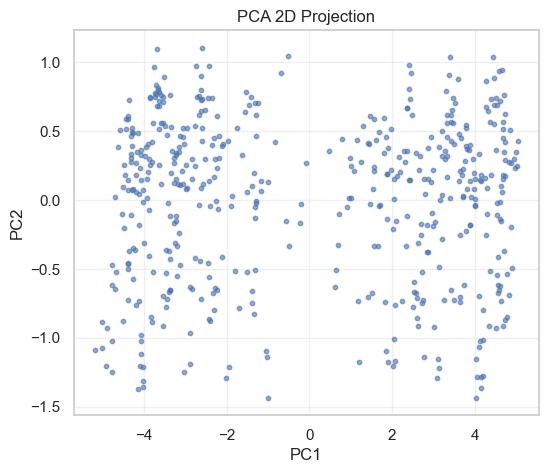

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_tr)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], s=10, alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D Projection")
plt.grid(True, alpha=0.3)
plt.show()

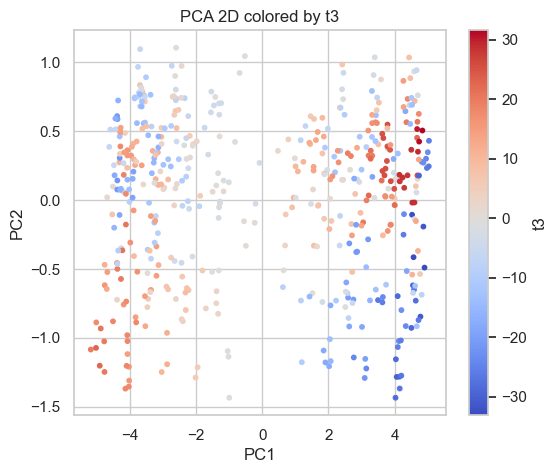

In [18]:
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1],
            c=df_train["t1"], cmap="coolwarm", s=10)
plt.colorbar(label="t3")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D colored by t3")
plt.show()

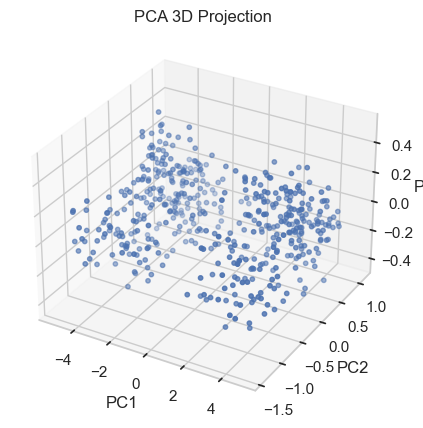

In [19]:
from mpl_toolkits.mplot3d import Axes3D

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], s=10)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.title("PCA 3D Projection")
plt.show()

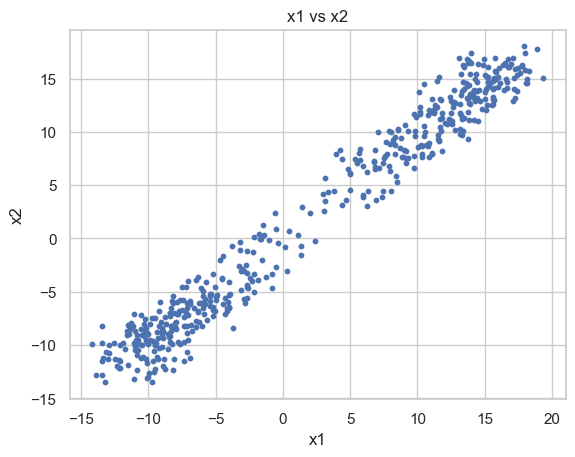

In [20]:
plt.scatter(df_train["x1"], df_train["x2"], s=10)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("x1 vs x2")
plt.show()

In [21]:
from sklearn.decomposition import PCA
import numpy as np

X = df_train[[f"x{i}" for i in range(1, 13)]].values

pca = PCA()
pca.fit(X)

explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

print("Explained variance ratio:", explained)
print("Cumulative explained variance:", cum_explained)

Explained variance ratio: [9.85371756e-01 2.83237864e-03 2.28762648e-03 1.81265375e-03
 1.60708913e-03 1.28625054e-03 1.10675430e-03 9.90881352e-04
 8.92249743e-04 7.53590778e-04 6.05004903e-04 4.53764009e-04]
Cumulative explained variance: [0.98537176 0.98820414 0.99049176 0.99230442 0.9939115  0.99519775
 0.99630451 0.99729539 0.99818764 0.99894123 0.99954624 1.        ]


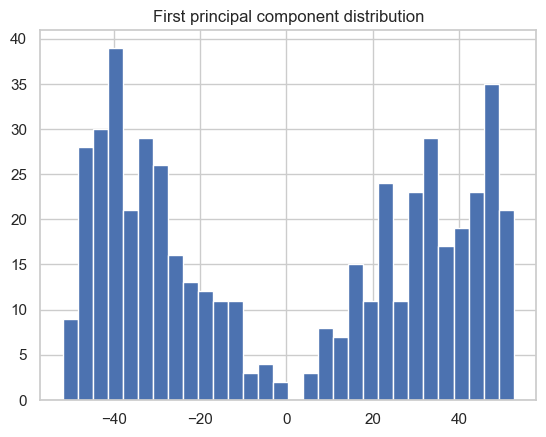

In [22]:
X_pca = pca.transform(X)
plt.hist(X_pca[:,0], bins=30)
plt.title("First principal component distribution")
plt.show()

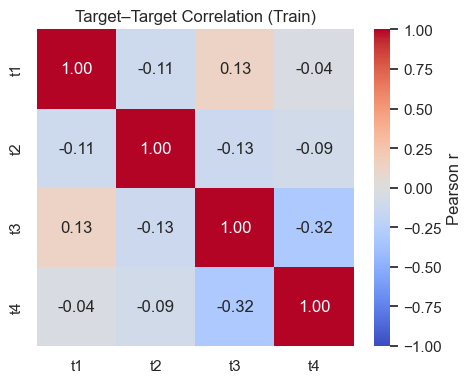

In [23]:
target_cols = df_train.columns[-4:]
corr = df_train[target_cols].corr(method="pearson")

plt.figure(figsize=(5, 4))
sns.heatmap(
    corr, annot=True,
    fmt=".2f",cmap="coolwarm",
    vmin=-1, vmax=1,
    square=True, cbar_kws={"label": "Pearson r"}
)

plt.title("Target–Target Correlation (Train)")
plt.tight_layout()
plt.show()

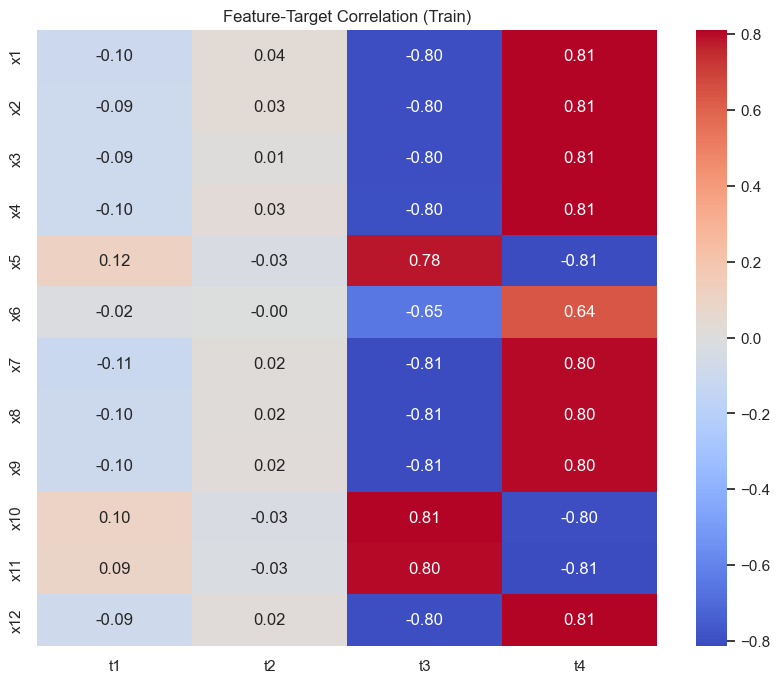

In [24]:
# Supponendo che 'df' sia il tuo DataFrame caricato dal CSV
# Selezioniamo solo le colonne di input e i target (escludendo l'ID)
# Le ultime 4 colonne sono i target
input_cols = df_train.columns[1:-4]
target_cols = df_train.columns[-4:]

# Calcoliamo la matrice di correlazione
corr_matrix = df_train[input_cols.tolist() + target_cols.tolist()].corr()

# Filtriamo per vedere solo la relazione tra Feature (righe) e Target (colonne)
feature_target_corr = corr_matrix.loc[input_cols, target_cols]

# Visualizzazione con Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(feature_target_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature-Target Correlation (Train)")
plt.show()

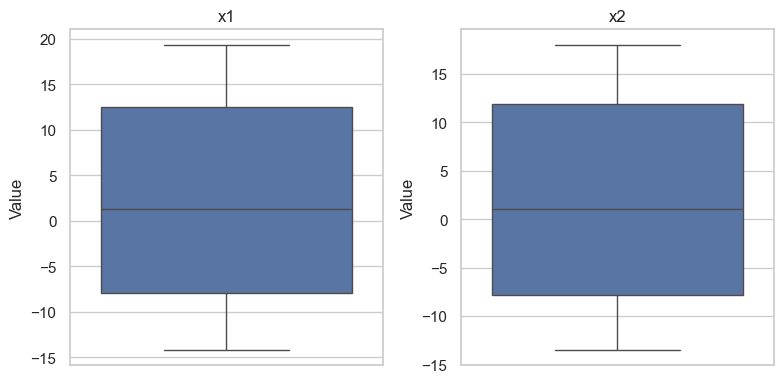

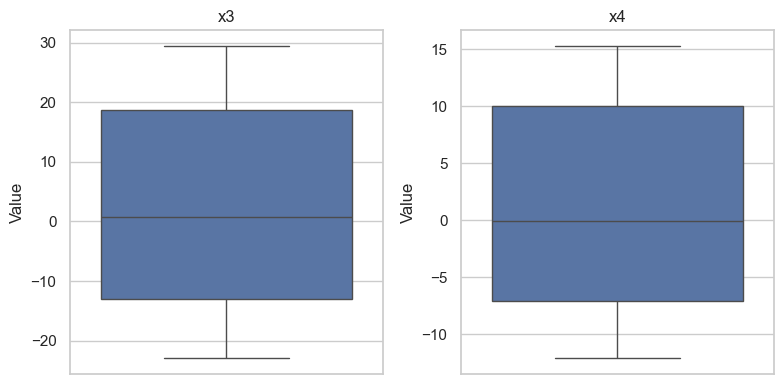

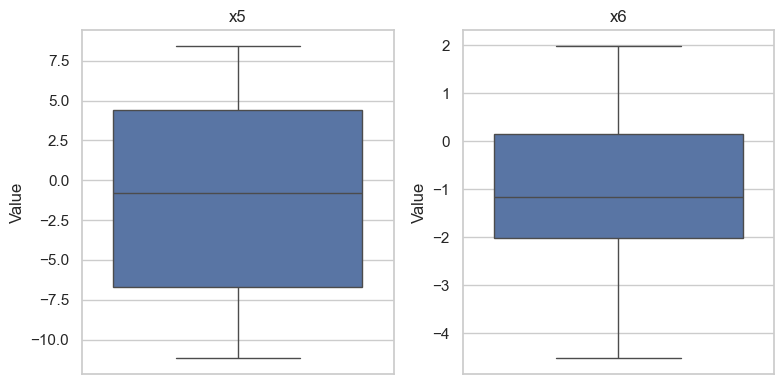

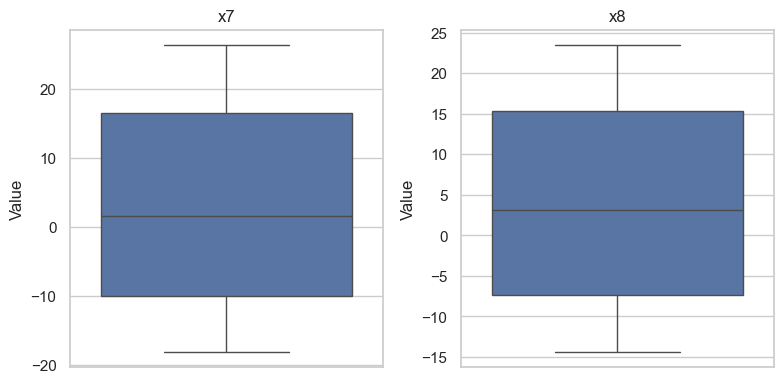

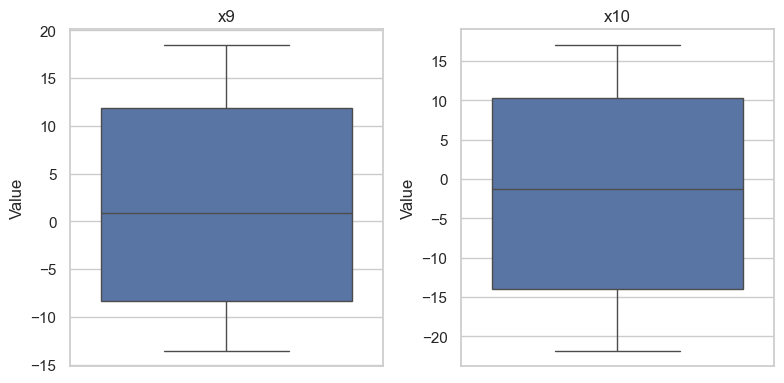

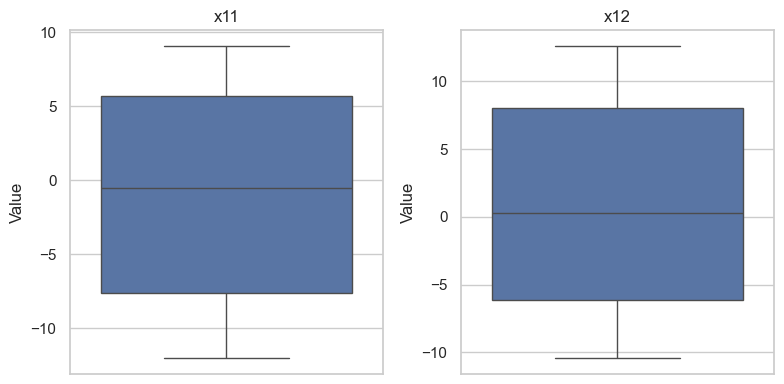

In [25]:

def boxplot_features_pairwise(df, features):
    """
    Pairwise boxplot of input features (ML-CUP style).
    Used to inspect scale differences and outliers.
    """

    for i in range(0, len(features), 2):

        fig, axes = plt.subplots(1, 2, figsize=(8, 4))

        # Left feature
        f1 = features[i]
        sns.boxplot(
            y=df[f1],
            ax=axes[0]
        )
        axes[0].set_title(f'{f1}')
        axes[0].set_ylabel('Value')

        # Right feature
        if i + 1 < len(features):
            f2 = features[i + 1]
            sns.boxplot(
                y=df[f2],
                ax=axes[1]
            )
            axes[1].set_title(f'{f2}')
            axes[1].set_ylabel('Value')
        else:
            axes[1].axis('off')

        plt.tight_layout()
        plt.show()


boxplot_features_pairwise(df_train, features_names)

In [26]:
importlib.reload(cc)
print(cr.model_baseline(X_tr, y_tr))

----------------------------------------
Baseline: DummyRegressor()
Mean baseline: 35.79302825927734
Scorer: make_scorer(neg_mean_euclidean_error, greater_is_better=False, response_method='predict')
Raw scores: [-36.10307312 -34.5480423  -35.62013626 -35.9157486  -36.77814102]
35.79302825927734
